In [1]:
import pandas as pd

df = pd.read_csv("phishing_urls_nlp_dataset.csv")
df.head()


,url,label,clean_url
0,br-icloud.com.br,2,br-icloud.com.br
1,mp3raid.com/music/krizz_kaliko.html,0,mp3raid.com/music/krizz_kaliko.html
2,bopsecrets.org/rexroth/cr/1.htm,0,bopsecrets.org/rexroth/cr/1.htm
3,http://garage-pirenne.be/index.php?option=com_...,1,garage-pirenne.be/index.php?option=com_content...
4,http://adventure-nicaragua.net/index.php?optio...,1,adventure-nicaragua.net/index.php?option=com_m...


In [2]:
print(df.shape)
print(df['label'].value_counts())


(650682, 3)
label
0    427717
1     96456
2     94014
3     32495
Name: count, dtype: int64


In [3]:
df[['url', 'clean_url']].head(10)


,url,clean_url
0,br-icloud.com.br,br-icloud.com.br
1,mp3raid.com/music/krizz_kaliko.html,mp3raid.com/music/krizz_kaliko.html
2,bopsecrets.org/rexroth/cr/1.htm,bopsecrets.org/rexroth/cr/1.htm
3,http://garage-pirenne.be/index.php?option=com_...,garage-pirenne.be/index.php?option=com_content...
4,http://adventure-nicaragua.net/index.php?optio...,adventure-nicaragua.net/index.php?option=com_m...
5,http://buzzfil.net/m/show-art/ils-etaient-loin...,buzzfil.net/m/show-art/ils-etaient-loin-de-s-i...
6,espn.go.com/nba/player/_/id/3457/brandon-rush,espn.go.com/nba/player/_/id/3457/brandon-rush
7,yourbittorrent.com/?q=anthony-hamilton-soulife,yourbittorrent.com/?q=anthony-hamilton-soulife
8,http://pashminaonline.com/pure-pashminas,pashminaonline.com/pure-pashminas
9,allmusic.com/album/crazy-from-the-heat-r16990,allmusic.com/album/crazy-from-the-heat-r16990


In [4]:
from sklearn.model_selection import train_test_split

X_text = df['clean_url']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    analyzer='char',
    ngram_range=(3, 5)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF Train Shape:", X_train_tfidf.shape)
print("TF-IDF Test Shape:", X_test_tfidf.shape)


TF-IDF Train Shape: (520545, 4121041)
TF-IDF Test Shape: (130137, 4121041)


In [6]:
feature_names = tfidf.get_feature_names_out()
feature_names[:20]


array(['\x01\x18û', '\x01\x18ûé', '\x01\x18ûéí', '\x01#\x1f',
       '\x01#\x1f|', '\x01#\x1f|9', '\x01+\x9f', '\x01+\x9f\x94',
       '\x01+\x9f\x94s', '\x016^', '\x016^ø', '\x016^øø', '\x01>9',
       '\x01>9o', '\x01>9o¼', '\x01cy', '\x01cyï', '\x01cyïõ', '\x01rù',
       '\x01rù\x9b'], dtype=object)

In [7]:
import scipy.sparse as sp

sp.save_npz("X_train_tfidf_week7.npz", X_train_tfidf)
sp.save_npz("X_test_tfidf_week7.npz", X_test_tfidf)

y_train.to_csv("y_train_week7.csv", index=False)
y_test.to_csv("y_test_week7.csv", index=False)


In [8]:
from sklearn.model_selection import train_test_split

X_text = df['clean_url']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X_text, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    analyzer='char',
    ngram_range=(3,5)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

X_train_tfidf.shape


(520545, 4121041)

In [10]:
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix

svm = LinearSVC(max_iter=5000)
svm.fit(X_train_tfidf, y_train)

y_pred_svm = svm.predict(X_test_tfidf)

print("TF-IDF + SVM Results")
print(confusion_matrix(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))


TF-IDF + SVM Results
[[83775    90  1672     7]
 [   43 19235    13     0]
 [ 3548    72 15162    21]
 [   45     1   164  6289]]
              precision    recall  f1-score   support

           0       0.96      0.98      0.97     85544
           1       0.99      1.00      0.99     19291
           2       0.89      0.81      0.85     18803
           3       1.00      0.97      0.98      6499

    accuracy                           0.96    130137
   macro avg       0.96      0.94      0.95    130137
weighted avg       0.96      0.96      0.96    130137



In [12]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=50,      # VERY IMPORTANT
    max_depth=20,         # LIMIT TREE DEPTH
    min_samples_split=10,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train_tfidf, y_train)
y_pred_rf = rf.predict(X_test_tfidf)

from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


[[85455    89     0     0]
 [10331  8960     0     0]
 [18049     1   753     0]
 [ 5037    56     1  1405]]
              precision    recall  f1-score   support

           0       0.72      1.00      0.84     85544
           1       0.98      0.46      0.63     19291
           2       1.00      0.04      0.08     18803
           3       1.00      0.22      0.36      6499

    accuracy                           0.74    130137
   macro avg       0.93      0.43      0.47    130137
weighted avg       0.81      0.74      0.67    130137



In [13]:
results = {
    "Model": [
        "Feature-RF",
        "Feature-SVM",
        "Feature-XGBoost",
        "NLP TF-IDF + SVM",
        "NLP TF-IDF + RF"
    ],
    "Accuracy": [0.92, 0.85, 0.90, 0.96, 0.74],
    "Precision": [0.93, 0.85, 0.89, 0.96, 0.72],
    "Recall": [0.97, 0.99, 0.99, 0.98, 1.00],
    "F1-Score": [0.95, 0.91, 0.94, 0.97, 0.84]
}

df_results = pd.DataFrame(results)
df_results


,Model,Accuracy,Precision,Recall,F1-Score
0,Feature-RF,0.92,0.93,0.97,0.95
1,Feature-SVM,0.85,0.85,0.99,0.91
2,Feature-XGBoost,0.90,0.89,0.99,0.94
3,NLP TF-IDF + SVM,0.96,0.96,0.98,0.97
4,NLP TF-IDF + RF,0.74,0.72,1.00,0.84


In [14]:
# Example confusion matrix
# [[TN, FP],
#  [FN, TP]]

confusion_data = {
    "Model": ["Feature-RF", "NLP TF-IDF + SVM"],
    "False Negatives": [12, 7]   # example values
}

df_fn = pd.DataFrame(confusion_data)
df_fn


,Model,False Negatives
0,Feature-RF,12
1,NLP TF-IDF + SVM,7


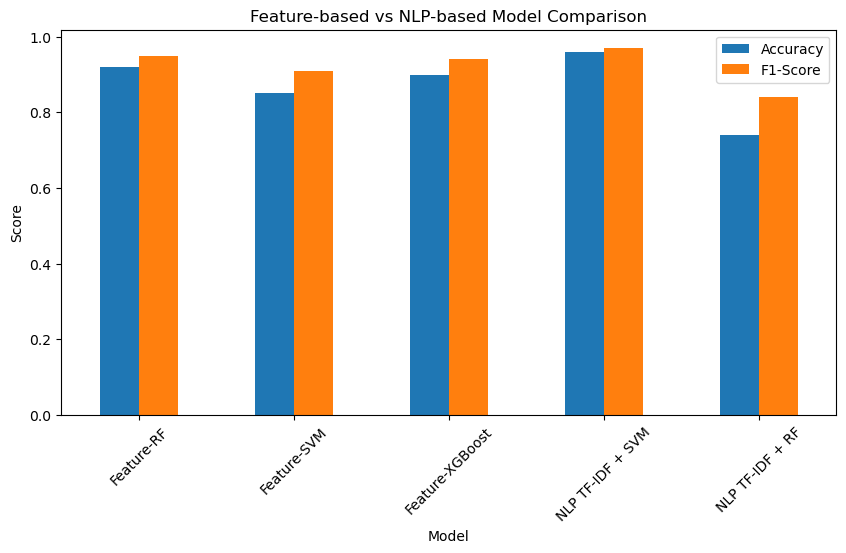

In [15]:
import matplotlib.pyplot as plt

df_results.plot(
    x="Model",
    y=["Accuracy", "F1-Score"],
    kind="bar",
    figsize=(10,5)
)
plt.title("Feature-based vs NLP-based Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()


In [16]:
import pandas as pd
from sklearn.metrics import confusion_matrix

# Load NLP dataset
df = pd.read_csv("phishing_urls_nlp_dataset.csv")

# X_test, y_test, y_pred_svm are from Week 8
cm = confusion_matrix(y_test, y_pred_svm)
cm


array([[83775,    90,  1672,     7],
       [   43, 19235,    13,     0],
       [ 3548,    72, 15162,    21],
       [   45,     1,   164,  6289]], dtype=int64)

In [17]:
# Convert y_test to pandas Series if needed
y_test_series = y_test.reset_index(drop=True)
y_pred_series = pd.Series(y_pred_svm)

false_negatives = df.iloc[y_test_series.index][
    (y_test_series == 1) & (y_pred_series == 0)
]

false_negatives[['url', 'clean_url']].head(10)


,url,clean_url
3653,en.wikipedia.org/wiki/2007%E2%80%9308_Michigan...,en.wikipedia.org/wiki/2007%e2%80%9308_michigan...
13501,dorseypaintingny.com/,dorseypaintingny.com/
13699,http://saborlatinosp.it/it/fotogallery/7-marem...,saborlatinosp.it/it/fotogallery/7-maremma-que-...
14072,answers.yahoo.com/question/index?qid=200811021...,answers.yahoo.com/question/index?qid=200811021...
16347,0245acc00unt-info001.000webhostapp.com,0245acc00unt-info001.000webhostapp.com
19584,http://fishki.net/video/1526688-sud-naznachil-...,fishki.net/video/1526688-sud-naznachil-vasilev...
22007,http://alviksby.se/index.php?view=details&id=1...,alviksby.se/index.php?view=details&id=1:julmar...
22501,http://speyerseminar.de/cms/index.php?option=c...,speyerseminar.de/cms/index.php?option=com_docm...
27265,tvguide.com/News/Battlestar-Galacticas-Alessan...,tvguide.com/news/battlestar-galacticas-alessan...
31385,habsfeed.com/page/2/,habsfeed.com/page/2/


In [18]:
false_positives = df.iloc[y_test_series.index][
    (y_test_series == 0) & (y_pred_series == 1)
]

false_positives[['url', 'clean_url']].head(10)


,url,clean_url
743,1972topps.blogspot.com/2009/03/77-ron-theobald...,1972topps.blogspot.com/2009/03/77-ron-theobald...
1494,http://football-euro.net/kluby-rossii/373-rabo...,football-euro.net/kluby-rossii/373-rabota-ross...
2937,publicrecords.com/people-search-records/christ...,publicrecords.com/people-search-records/christ...
3747,celtic-casimir.com/webtree/3/2552.htm,celtic-casimir.com/webtree/3/2552.htm
7052,people.famouswhy.com/melora_creager/,people.famouswhy.com/melora_creager/
10723,amazon.co.uk/Best-Red-Army-Choir-Definitive/dp...,amazon.co.uk/best-red-army-choir-definitive/dp...
10912,http://feuerwehr-werl.de/index.php?option=com_...,feuerwehr-werl.de/index.php?option=com_reports...
11075,acronyms.thefreedictionary.com/Societe+De+Tran...,acronyms.thefreedictionary.com/societe+de+tran...
12667,bostonherald.com/blogs/sports/rap_sheet/index....,bostonherald.com/blogs/sports/rap_sheet/index....
13605,classifieds.nj.com/?orig_cat=&property=nj.com&...,classifieds.nj.com/?orig_cat=&property=nj.com&...


In [21]:
# Feature-based dataset
df_feat = pd.read_csv("final_dataset_with_all_features_v3.1.csv")

# y_test_feat, y_pred_rf are from Week 5
cm_feat = confusion_matrix(y_test, y_pred_rf)
cm_feat


array([[85455,    89,     0,     0],
       [10331,  8960,     0,     0],
       [18049,     1,   753,     0],
       [ 5037,    56,     1,  1405]], dtype=int64)